This notebook is intended for statistical analysis of episodic pivots (ep) prior to the ep peak with the aim of successfully shorting the stock. It will be focused on the first few days after the ep is initited. If the notebook becomes too dense other branches may be created.

In [1]:
%run "..\scripts\load_daily_variables.py"

Loading Variables: 100%|██████████| 27/27 [06:20<00:00, 14.10s/it]  


In [2]:
import numpy as np
import pandas as pd
from IPython.display import display

from market_data.price_data_import import fragmented_intraday_import

# Select EPs by their start date. Once selected, fetch each EP's complete
# duration, including dates after EP_END_DATE.
EP_START_DATE = "2026-01-01"  # Example: "2024-01-01"
EP_END_DATE = None  # Example: "2025-12-31"
TIMEFRAME = "3min"


def _normalized_bound(value):
    return None if value is None else pd.Timestamp(value).normalize()


def _selected_episodic_pivots(ep_object, start_date=None, end_date=None):
    start_bound = _normalized_bound(start_date)
    end_bound = _normalized_bound(end_date)
    rows = []

    for symbol, pivots in ep_object.ep_dict.items():
        for ep_key, ep_frame in pivots.items():
            if ep_frame is None or ep_frame.empty:
                continue

            ep_start = pd.Timestamp(ep_key).normalize()
            if start_bound is not None and ep_start < start_bound:
                continue
            if end_bound is not None and ep_start > end_bound:
                continue

            rows.append(
                {
                    "symbol": str(symbol).strip().upper(),
                    "ep_start": ep_start,
                    "ep_end": pd.Timestamp(ep_frame.index.max()).normalize(),
                }
            )

    result = pd.DataFrame(rows, columns=["symbol", "ep_start", "ep_end"])
    if not result.empty:
        result = result.sort_values(
            ["symbol", "ep_start", "ep_end"]
        ).reset_index(drop=True)
    return result


def _merge_fetch_ranges(selected_ep_rows):
    """Merge overlapping or adjacent EP ranges to avoid duplicate API calls."""
    ranges_by_symbol = {}

    for symbol, symbol_eps in selected_ep_rows.groupby("symbol", sort=False):
        periods = sorted(zip(symbol_eps["ep_start"], symbol_eps["ep_end"]))
        merged = []
        for period_start, period_end in periods:
            if not merged or period_start > merged[-1][1] + pd.Timedelta(days=1):
                merged.append([period_start, period_end])
            else:
                merged[-1][1] = max(merged[-1][1], period_end)

        ranges_by_symbol[symbol] = [
            (period_start.date(), period_end.date())
            for period_start, period_end in merged
        ]

    return ranges_by_symbol


def _session_bars(one_minute_rows, timeframe=TIMEFRAME):
    """Build intraday bars independently for each regular-hours session."""
    if one_minute_rows is None or one_minute_rows.empty:
        return pd.DataFrame()

    data = one_minute_rows.copy()
    data.index = pd.to_datetime(data.index)
    data = data.sort_index()
    data = data[~data.index.duplicated(keep="last")]
    data = data.between_time("09:30", "15:59:59")

    sessions = []
    for _, day in data.groupby(data.index.normalize(), sort=True):
        day = day[["Open", "High", "Low", "Close", "Volume"]].apply(
            pd.to_numeric, errors="coerce"
        )
        day = day.dropna(subset=["Open", "High", "Low", "Close", "Volume"])
        if day.empty:
            continue

        bars = day.resample(timeframe).agg(
            {
                "Open": "first",
                "High": "max",
                "Low": "min",
                "Close": "last",
                "Volume": "sum",
            }
        )
        bars = bars.dropna(subset=["Open", "High", "Low", "Close"])
        if not bars.empty:
            sessions.append(bars)

    return pd.concat(sessions).sort_index() if sessions else pd.DataFrame()


selected_eps = _selected_episodic_pivots(ep, EP_START_DATE, EP_END_DATE)
if selected_eps.empty:
    raise ValueError("No episodic pivots begin within the configured interval.")

fetch_ranges = _merge_fetch_ranges(selected_eps)
raw_intraday = fragmented_intraday_import(
    fetch_ranges,
    timespan="minute",
    multiplier=1,
    resample=False,
    limit=50_000,
)

intraday_3min = {}
for symbol, frames in raw_intraday.items():
    usable_frames = [
        frame for frame in frames if frame is not None and not frame.empty
    ]
    if usable_frames:
        intraday_3min[symbol] = _session_bars(
            pd.concat(usable_frames), timeframe=TIMEFRAME
        )

print(
    f"Selected EPs: {len(selected_eps):,} | "
    f"Symbols with intraday data: {len(intraday_3min):,}"
)

Importing Price Data: 100%|██████████| 1924/1924 [05:59<00:00,  5.35it/s]
Selected EPs: 2,332 | Symbols with intraday data: 1,216


## First Day Comparisons

- First Day

In [3]:
first_five_day_records = []

for ep_row in selected_eps.itertuples(index=False):
    symbol_bars = intraday_3min.get(ep_row.symbol)
    if symbol_bars is None or symbol_bars.empty:
        continue

    ep_bars = symbol_bars.loc[
        (symbol_bars.index.normalize() >= ep_row.ep_start)
        & (symbol_bars.index.normalize() <= ep_row.ep_end)
    ]
    if ep_bars.empty:
        continue

    sessions = list(ep_bars.groupby(ep_bars.index.normalize(), sort=True))
    first_session_bars = sessions[0][1]
    record = {
        "symbol": ep_row.symbol,
        "ep_start": ep_row.ep_start,
        "first_day_open": float(first_session_bars.iloc[0]["Open"]),
    }

    for day_number in range(1, 6):
        close_col = f"day_{day_number}_close"
        record[close_col] = (
            float(sessions[day_number - 1][1].iloc[-1]["Close"])
            if len(sessions) >= day_number
            else np.nan
        )

    first_five_day_records.append(record)

first_five_day_results = pd.DataFrame(first_five_day_records)
if first_five_day_results.empty:
    raise ValueError("No price data is available for the selected episodic pivots.")

summary_rows = []
for day_number in range(1, 6):
    close_col = f"day_{day_number}_close"
    lower_col = f"closed_lower_day_{day_number}"
    has_close = first_five_day_results[close_col].notna()
    first_five_day_results[lower_col] = pd.Series(
        np.where(
            has_close,
            first_five_day_results[close_col]
            < first_five_day_results["first_day_open"],
            pd.NA,
        ),
        index=first_five_day_results.index,
        dtype="boolean",
    )

    observations = int(has_close.sum())
    closed_lower = int(first_five_day_results[lower_col].sum(skipna=True))
    probability = closed_lower / observations if observations else np.nan
    summary_rows.append(
        {
            "ep_day": day_number,
            "observations": observations,
            "closed_lower_than_first_day_open": closed_lower,
            "probability": probability,
            "probability_pct": probability * 100,
        }
    )

first_five_day_summary = pd.DataFrame(summary_rows).set_index("ep_day")

display(first_five_day_summary)
display(first_five_day_results)

,observations,closed_lower_than_first_day_open,probability,probability_pct
ep_day,,,,
1,2332,1258,0.539451,53.945111
2,2327,1254,0.538891,53.889128
3,2201,1162,0.527942,52.794184
4,2089,1040,0.497846,49.784586
5,1976,956,0.483806,48.380567


,symbol,ep_start,first_day_open,day_1_close,day_2_close,day_3_close,day_4_close,day_5_close,closed_lower_day_1,closed_lower_day_2,closed_lower_day_3,closed_lower_day_4,closed_lower_day_5
0,A,2026-05-28,133.000,135.400,135.520,136.050,135.04,137.430,False,False,False,False,False
1,AA,2026-03-30,64.000,63.220,66.310,72.070,71.52,71.020,True,False,False,False,False
2,AAL,2026-04-08,12.030,11.430,11.375,11.305,11.22,12.140,True,True,True,True,False
3,AAOI,2026-02-27,65.930,84.240,102.500,95.370,99.71,101.150,False,False,False,False,False
4,AAOI,2026-03-02,107.550,102.500,95.370,99.710,101.15,95.510,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2327,ZM,2026-05-22,108.500,105.630,100.055,NaN,NaN,NaN,True,True,<NA>,<NA>,<NA>
2328,ZNTL,2026-01-09,3.130,3.735,3.485,3.480,3.52,3.165,False,False,False,False,False
2329,ZNTL,2026-04-09,3.020,4.430,6.610,5.570,5.19,5.355,False,False,False,False,False
2330,ZVRA,2026-03-10,10.950,11.060,10.400,10.190,9.97,9.890,False,True,True,True,True


- First Day with Quant Rating

The following cell uses the most recent quant rating. I should update it to select the quant rating at ep start.

In [4]:
QUANT_RATING = 3

latest_quant_rating_col = daily_quant_rating_df.columns[-2]
latest_quant_ratings = pd.to_numeric(
    daily_quant_rating_df[latest_quant_rating_col], errors="coerce"
)
latest_quant_ratings.index = (
    latest_quant_ratings.index.astype(str).str.strip().str.upper()
)

first_five_days_with_quant_rating = first_five_day_results.copy()
first_five_days_with_quant_rating["latest_quant_rating"] = (
    first_five_days_with_quant_rating["symbol"].map(latest_quant_ratings)
)

quant_under_4 = first_five_days_with_quant_rating.loc[
    first_five_days_with_quant_rating["latest_quant_rating"].lt(QUANT_RATING)
].copy()
if quant_under_4.empty:
    raise ValueError(
        f"No selected episodic pivots have a quant rating below 4 in "
        f"{latest_quant_rating_col}."
    )

conditional_summary_rows = []
for day_number in range(1, 6):
    lower_col = f"closed_lower_day_{day_number}"
    valid = quant_under_4[lower_col].notna()
    observations = int(valid.sum())
    closed_lower = int(quant_under_4.loc[valid, lower_col].sum())
    probability = closed_lower / observations if observations else np.nan
    conditional_summary_rows.append(
        {
            "ep_day": day_number,
            "quant_rating_column": latest_quant_rating_col,
            "observations": observations,
            "closed_lower_than_first_day_open": closed_lower,
            "conditional_probability": probability,
            "conditional_probability_pct": probability * 100,
        }
    )

quant_under_4_summary = pd.DataFrame(conditional_summary_rows).set_index("ep_day")

display(quant_under_4_summary)
display(quant_under_4)

,quant_rating_column,observations,closed_lower_than_first_day_open,conditional_probability,conditional_probability_pct
ep_day,,,,,
1,2026-08-17,598,361,0.603679,60.367893
2,2026-08-17,596,362,0.607383,60.738255
3,2026-08-17,547,326,0.595978,59.597806
4,2026-08-17,519,292,0.562620,56.262042
5,2026-08-17,493,270,0.547667,54.766734


,symbol,ep_start,first_day_open,day_1_close,day_2_close,day_3_close,day_4_close,day_5_close,closed_lower_day_1,closed_lower_day_2,closed_lower_day_3,closed_lower_day_4,closed_lower_day_5,latest_quant_rating
1,AA,2026-03-30,64.000,63.220,66.310,72.070,71.520,71.020,True,False,False,False,False,2.749569
33,ACDC,2026-08-13,5.580,5.260,5.375,5.295,NaN,NaN,True,True,True,<NA>,<NA>,2.841388
34,ACEL,2026-03-04,13.000,13.070,12.190,11.700,11.475,11.450,False,True,True,True,True,2.921125
48,ACVA,2026-03-03,5.290,5.540,5.465,5.415,5.110,5.160,False,False,False,True,True,2.960131
49,ACVA,2026-05-07,6.174,6.500,6.400,6.090,5.835,5.650,False,False,True,True,True,2.960131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2304,XPOF,2026-04-07,7.300,7.255,7.360,7.570,7.600,7.510,True,False,False,False,False,1.435374
2305,XPOF,2026-05-20,5.250,5.500,5.570,5.710,5.770,5.810,False,False,False,False,False,1.435374
2310,YELP,2026-08-07,27.110,25.530,24.570,23.620,23.650,24.390,True,True,True,True,True,2.771315
2328,ZNTL,2026-01-09,3.130,3.735,3.485,3.480,3.520,3.165,False,False,False,False,False,2.790991


## First Week Open/Close Probabilities.

In [5]:
same_day_open_close_records = []

for ep_row in selected_eps.itertuples(index=False):
    symbol_bars = intraday_3min.get(ep_row.symbol)
    if symbol_bars is None or symbol_bars.empty:
        continue

    ep_bars = symbol_bars.loc[
        (symbol_bars.index.normalize() >= ep_row.ep_start)
        & (symbol_bars.index.normalize() <= ep_row.ep_end)
    ]
    if ep_bars.empty:
        continue

    sessions = list(ep_bars.groupby(ep_bars.index.normalize(), sort=True))
    record = {"symbol": ep_row.symbol, "ep_start": ep_row.ep_start}

    for day_number in range(1, 6):
        open_col = f"day_{day_number}_open"
        close_col = f"day_{day_number}_close"
        if len(sessions) >= day_number:
            session_bars = sessions[day_number - 1][1]
            record[open_col] = float(session_bars.iloc[0]["Open"])
            record[close_col] = float(session_bars.iloc[-1]["Close"])
        else:
            record[open_col] = np.nan
            record[close_col] = np.nan

    same_day_open_close_records.append(record)

same_day_open_close_results = pd.DataFrame(same_day_open_close_records)
if same_day_open_close_results.empty:
    raise ValueError("No price data is available for the selected episodic pivots.")

same_day_summary_rows = []
for day_number in range(1, 6):
    open_col = f"day_{day_number}_open"
    close_col = f"day_{day_number}_close"
    lower_col = f"closed_lower_same_day_{day_number}"
    valid = same_day_open_close_results[[open_col, close_col]].notna().all(axis=1)

    same_day_open_close_results[lower_col] = pd.Series(
        np.where(
            valid,
            same_day_open_close_results[close_col]
            < same_day_open_close_results[open_col],
            pd.NA,
        ),
        index=same_day_open_close_results.index,
        dtype="boolean",
    )

    observations = int(valid.sum())
    closed_lower = int(
        same_day_open_close_results[lower_col].sum(skipna=True)
    )
    probability = closed_lower / observations if observations else np.nan
    same_day_summary_rows.append(
        {
            "ep_day": day_number,
            "observations": observations,
            "closed_lower_than_same_day_open": closed_lower,
            "probability": probability,
            "probability_pct": probability * 100,
        }
    )

same_day_open_close_summary = pd.DataFrame(same_day_summary_rows).set_index(
    "ep_day"
)

display(same_day_open_close_summary)
display(same_day_open_close_results)

,observations,closed_lower_than_same_day_open,probability,probability_pct
ep_day,,,,
1,2332,1258,0.539451,53.945111
2,2327,1217,0.522991,52.299098
3,2201,1135,0.515675,51.567469
4,2089,983,0.470560,47.056008
5,1976,1072,0.542510,54.251012


,symbol,ep_start,day_1_open,day_1_close,day_2_open,day_2_close,day_3_open,day_3_close,day_4_open,day_4_close,day_5_open,day_5_close,closed_lower_same_day_1,closed_lower_same_day_2,closed_lower_same_day_3,closed_lower_same_day_4,closed_lower_same_day_5
0,A,2026-05-28,133.000,135.400,136.250,135.520,133.500,136.050,133.28,135.04,134.220,137.430,False,True,False,False,False
1,AA,2026-03-30,64.000,63.220,64.870,66.310,67.580,72.070,70.78,71.52,71.920,71.020,True,False,False,False,True
2,AAL,2026-04-08,12.030,11.430,11.315,11.375,11.450,11.305,11.00,11.22,12.055,12.140,True,False,True,False,False
3,AAOI,2026-02-27,65.930,84.240,107.550,102.500,91.500,95.370,101.20,99.71,97.490,101.150,False,True,False,True,False
4,AAOI,2026-03-02,107.550,102.500,91.500,95.370,101.200,99.710,97.49,101.15,98.000,95.510,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2327,ZM,2026-05-22,108.500,105.630,105.215,100.055,NaN,NaN,NaN,NaN,NaN,NaN,True,True,<NA>,<NA>,<NA>
2328,ZNTL,2026-01-09,3.130,3.735,3.850,3.485,3.370,3.480,3.46,3.52,3.500,3.165,False,True,False,False,True
2329,ZNTL,2026-04-09,3.020,4.430,4.520,6.610,6.405,5.570,5.56,5.19,5.200,5.355,False,False,True,True,False
2330,ZVRA,2026-03-10,10.950,11.060,10.760,10.400,10.240,10.190,10.10,9.97,10.537,9.890,False,True,True,True,True


The following cell uses the most recent quant rating. I should update it to select the quant rating at ep start.

In [6]:
same_day_with_quant_rating = same_day_open_close_results.copy()
same_day_with_quant_rating["latest_quant_rating"] = (
    same_day_with_quant_rating["symbol"].map(latest_quant_ratings)
)

same_day_quant_under_4 = same_day_with_quant_rating.loc[
    same_day_with_quant_rating["latest_quant_rating"].lt(QUANT_RATING)
].copy()
if same_day_quant_under_4.empty:
    raise ValueError(
        f"No selected episodic pivots have a quant rating below "
        f"{QUANT_RATING} in {latest_quant_rating_col}."
    )

same_day_conditional_rows = []
for day_number in range(1, 6):
    lower_col = f"closed_lower_same_day_{day_number}"
    valid = same_day_quant_under_4[lower_col].notna()
    observations = int(valid.sum())
    closed_lower = int(same_day_quant_under_4.loc[valid, lower_col].sum())
    probability = closed_lower / observations if observations else np.nan
    same_day_conditional_rows.append(
        {
            "ep_day": day_number,
            "quant_rating_column": latest_quant_rating_col,
            "observations": observations,
            "closed_lower_than_same_day_open": closed_lower,
            "conditional_probability": probability,
            "conditional_probability_pct": probability * 100,
        }
    )

same_day_quant_under_4_summary = pd.DataFrame(
    same_day_conditional_rows
).set_index("ep_day")

display(same_day_quant_under_4_summary)
display(same_day_quant_under_4)

,quant_rating_column,observations,closed_lower_than_same_day_open,conditional_probability,conditional_probability_pct
ep_day,,,,,
1,2026-08-17,598,361,0.603679,60.367893
2,2026-08-17,596,326,0.546980,54.697987
3,2026-08-17,547,296,0.541133,54.113346
4,2026-08-17,519,225,0.433526,43.352601
5,2026-08-17,493,258,0.523327,52.332657


,symbol,ep_start,day_1_open,day_1_close,day_2_open,day_2_close,day_3_open,day_3_close,day_4_open,day_4_close,day_5_open,day_5_close,closed_lower_same_day_1,closed_lower_same_day_2,closed_lower_same_day_3,closed_lower_same_day_4,closed_lower_same_day_5,latest_quant_rating
1,AA,2026-03-30,64.000,63.220,64.87,66.310,67.580,72.070,70.78,71.520,71.92,71.020,True,False,False,False,True,2.749569
33,ACDC,2026-08-13,5.580,5.260,5.26,5.375,5.365,5.295,NaN,NaN,NaN,NaN,True,False,True,<NA>,<NA>,2.841388
34,ACEL,2026-03-04,13.000,13.070,13.00,12.190,11.880,11.700,11.44,11.475,11.36,11.450,False,True,True,False,False,2.921125
48,ACVA,2026-03-03,5.290,5.540,5.44,5.465,5.440,5.415,5.32,5.110,5.00,5.160,False,False,True,True,False,2.960131
49,ACVA,2026-05-07,6.174,6.500,6.31,6.400,6.310,6.090,6.11,5.835,5.74,5.650,False,False,True,True,True,2.960131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2304,XPOF,2026-04-07,7.300,7.255,7.54,7.360,7.270,7.570,7.57,7.600,7.50,7.510,True,True,False,False,False,1.435374
2305,XPOF,2026-05-20,5.250,5.500,5.39,5.570,5.900,5.710,5.78,5.770,5.84,5.810,False,False,True,True,True,1.435374
2310,YELP,2026-08-07,27.110,25.530,25.22,24.570,24.410,23.620,23.19,23.650,23.38,24.390,True,True,True,False,False,2.771315
2328,ZNTL,2026-01-09,3.130,3.735,3.85,3.485,3.370,3.480,3.46,3.520,3.50,3.165,False,True,False,False,True,2.790991


In [7]:
day_1_mean_returns_by_symbol = (
    same_day_open_close_results.assign(
        day_1_return=(
            same_day_open_close_results["day_1_close"]
            / same_day_open_close_results["day_1_open"]
            - 1
        )
    )
    .groupby("symbol", as_index=False)["day_1_return"]
    .mean()
    .sort_values("day_1_return", ascending=True)
    .reset_index(drop=True)
)

display(day_1_mean_returns_by_symbol.head(60))

,symbol,day_1_return
0,CAR,-0.429618
1,DOCS,-0.294738
2,ALMS,-0.268018
3,DRUG,-0.222037
4,DSGN,-0.198773
5,AMSC,-0.182491
6,GEMI,-0.175686
7,ALNY,-0.174007
8,TLRY,-0.172195
9,ITGR,-0.171100


## First Week Open/Close Machine Learning

- Agglomerative Clustering with cumulative returns.
- A more overall returns focused machine learning result.

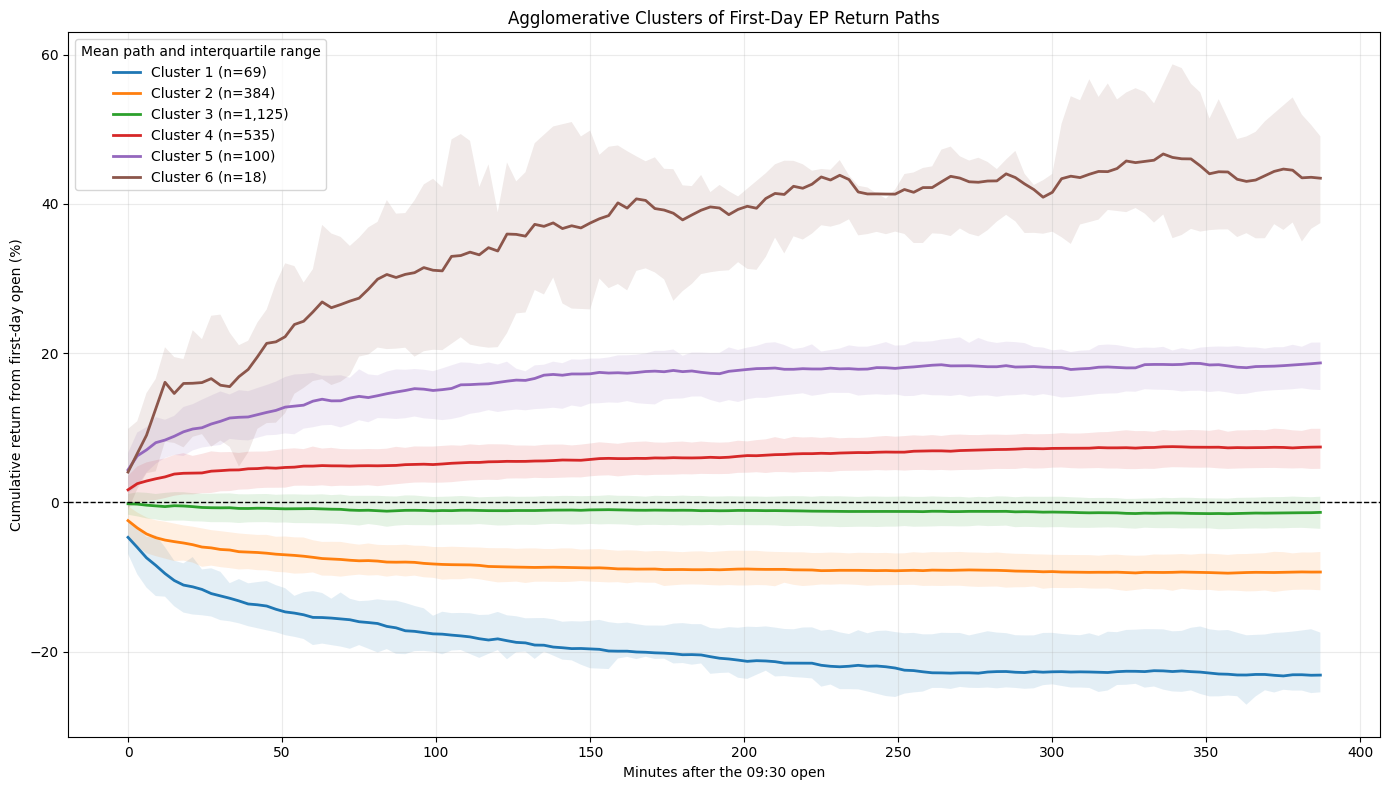

,episodic_pivots,unique_symbols,mean_first_day_return_pct,median_first_day_return_pct,percent_closing_lower
cluster,,,,,
1,69,55,-23.118465,-20.822281,100.000000
2,384,321,-9.315170,-8.858651,99.218750
3,1125,785,-1.324864,-1.094447,65.155556
4,535,414,7.429698,6.613258,1.869159
5,100,87,18.690751,17.806670,0.000000
6,18,14,43.432512,40.704781,0.000000


,symbol,ep_start,first_day_open,cluster,first_day_return,first_day_return_pct
0,BIYA,2026-07-20,7.7800,1,-0.550771,-55.077121
1,KIDZ,2026-07-21,14.6550,1,-0.436745,-43.674514
2,SDOT,2026-07-02,88.9900,1,-0.431734,-43.173390
3,CAR,2026-04-22,774.9900,1,-0.429618,-42.961845
4,GPUS,2026-06-24,0.3199,1,-0.416380,-41.638012
...,...,...,...,...,...,...
2226,ACRS,2026-01-20,2.9500,6,0.498305,49.830508
2227,SDOT,2026-06-17,11.0000,6,0.563636,56.363636
2228,CRVS,2026-01-20,13.5100,6,0.583272,58.327165
2229,SDOT,2026-07-01,44.7000,6,0.602349,60.234899


In [8]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

N_CLUSTERS = 6
BARS_PER_SESSION = 130  # 09:30 through 15:59 on a three-minute timeframe
MAX_CONSECUTIVE_MISSING_BARS = 2

trajectory_rows = []
trajectory_metadata = []

for ep_row in selected_eps.itertuples(index=False):
    symbol_bars = intraday_3min.get(ep_row.symbol)
    if symbol_bars is None or symbol_bars.empty:
        continue

    first_day_bars = symbol_bars.loc[
        symbol_bars.index.normalize() == ep_row.ep_start
    ].copy()
    if first_day_bars.empty:
        continue

    minutes_after_midnight = (
        first_day_bars.index.hour * 60 + first_day_bars.index.minute
    )
    first_day_bars["bar_number"] = (
        (minutes_after_midnight - (9 * 60 + 30)) // 3
    )
    first_day_bars = first_day_bars.loc[
        first_day_bars["bar_number"].between(0, BARS_PER_SESSION - 1)
    ]
    first_day_bars = first_day_bars.drop_duplicates(
        subset="bar_number", keep="last"
    ).set_index("bar_number")

    if 0 not in first_day_bars.index:
        continue

    first_day_open = float(first_day_bars.loc[0, "Open"])
    if not np.isfinite(first_day_open) or first_day_open <= 0:
        continue

    # A cumulative return path preserves both the direction and magnitude of
    # the move relative to the EP day's opening print.
    return_path = (
        first_day_bars["Close"].reindex(range(BARS_PER_SESSION))
        / first_day_open
        - 1
    )
    return_path = return_path.interpolate(
        method="linear",
        limit=MAX_CONSECUTIVE_MISSING_BARS,
        limit_area="inside",
    )

    # Exclude partial sessions and days with data gaps too large to interpolate.
    if return_path.isna().any():
        continue

    trajectory_rows.append(return_path.to_numpy(dtype=float))
    trajectory_metadata.append(
        {
            "symbol": ep_row.symbol,
            "ep_start": ep_row.ep_start,
            "first_day_open": first_day_open,
        }
    )

if len(trajectory_rows) < N_CLUSTERS:
    raise ValueError(
        f"Only {len(trajectory_rows)} complete first-day trajectories are "
        f"available for {N_CLUSTERS} clusters."
    )

first_day_return_matrix = np.vstack(trajectory_rows)
cluster_model = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    linkage="ward",
)
raw_cluster_labels = cluster_model.fit_predict(first_day_return_matrix)

# Ward cluster labels are arbitrary. Renumber clusters from the lowest to the
# highest mean closing return so repeated analysis is easier to interpret.
cluster_final_return_means = {
    label: first_day_return_matrix[raw_cluster_labels == label, -1].mean()
    for label in np.unique(raw_cluster_labels)
}
ordered_labels = sorted(cluster_final_return_means, key=cluster_final_return_means.get)
cluster_number_map = {
    original_label: cluster_number
    for cluster_number, original_label in enumerate(ordered_labels, start=1)
}
cluster_labels = np.array(
    [cluster_number_map[label] for label in raw_cluster_labels]
)

first_day_cluster_assignments = pd.DataFrame(trajectory_metadata)
first_day_cluster_assignments["cluster"] = cluster_labels
first_day_cluster_assignments["first_day_return"] = first_day_return_matrix[:, -1]
first_day_cluster_assignments["first_day_return_pct"] = (
    first_day_cluster_assignments["first_day_return"] * 100
)

first_day_cluster_summary = (
    first_day_cluster_assignments.groupby("cluster")
    .agg(
        episodic_pivots=("symbol", "size"),
        unique_symbols=("symbol", "nunique"),
        mean_first_day_return_pct=("first_day_return_pct", "mean"),
        median_first_day_return_pct=("first_day_return_pct", "median"),
        percent_closing_lower=(
            "first_day_return",
            lambda returns: returns.lt(0).mean() * 100,
        ),
    )
    .sort_index()
)

minute_columns = pd.Index(
    np.arange(BARS_PER_SESSION) * 3, name="minutes_after_open"
)
first_day_return_paths = pd.DataFrame(
    first_day_return_matrix,
    columns=minute_columns,
)
first_day_return_paths.insert(0, "cluster", cluster_labels)
first_day_return_paths.insert(0, "ep_start", first_day_cluster_assignments["ep_start"])
first_day_return_paths.insert(0, "symbol", first_day_cluster_assignments["symbol"])

fig, ax = plt.subplots(figsize=(14, 8))
minutes = minute_columns.to_numpy()
for cluster_number in range(1, N_CLUSTERS + 1):
    cluster_paths = first_day_return_matrix[cluster_labels == cluster_number]
    mean_path = cluster_paths.mean(axis=0) * 100
    lower_quartile = np.quantile(cluster_paths, 0.25, axis=0) * 100
    upper_quartile = np.quantile(cluster_paths, 0.75, axis=0) * 100
    ax.plot(
        minutes,
        mean_path,
        linewidth=2,
        label=f"Cluster {cluster_number} (n={len(cluster_paths):,})",
    )
    ax.fill_between(minutes, lower_quartile, upper_quartile, alpha=0.12)

ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Agglomerative Clusters of First-Day EP Return Paths")
ax.set_xlabel("Minutes after the 09:30 open")
ax.set_ylabel("Cumulative return from first-day open (%)")
ax.legend(title="Mean path and interquartile range")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(first_day_cluster_summary)
display(
    first_day_cluster_assignments.sort_values(
        ["cluster", "first_day_return"], ascending=[True, True]
    ).reset_index(drop=True)
)

In [9]:
def quant_rating_by_date(sym, date):
    try:
        date = pd.to_datetime(date).strftime("%Y-%m-%d")
        return daily_quant_rating_df.loc[sym, date]
    except:
        return np.nan
first_day_cluster_assignments['quant_rating'] = first_day_cluster_assignments.apply(
    lambda row: quant_rating_by_date(row['symbol'], row['ep_start']), axis=1
)
first_day_cluster_assignments.groupby('cluster')['quant_rating'].median().head(60)

cluster
1    2.825869
2    2.886851
3    3.038354
4    3.077208
5    2.927047
6    3.082208
Name: quant_rating, dtype: float64

In [10]:
first_day_cluster_assignments.loc[first_day_cluster_assignments['cluster'] == 1][['symbol', 'ep_start', 'quant_rating']].sort_values('quant_rating', ascending=False).head(60)

,symbol,ep_start,quant_rating
1346,NVST,2026-05-07,4.615616
976,INOD,2026-08-07,4.523055
1464,PDYN,2026-03-18,4.478916
493,COHU,2026-07-31,4.350667
163,APPS,2026-02-04,4.119048
1954,TNDM,2026-05-08,3.587613
412,CAR,2026-04-22,3.487426
105,ALLO,2026-04-13,3.464066
2000,UAMY,2026-01-26,3.331760
1962,TROX,2026-02-19,3.197242


In [11]:
(
    first_day_cluster_assignments
    .loc[first_day_cluster_assignments['cluster'] == 6]
    .sort_values("ep_start", ascending=True)
    .reset_index(drop=True)
    .head(60)
)

,symbol,ep_start,first_day_open,cluster,first_day_return,first_day_return_pct,quant_rating
0,SKYQ,2026-01-06,2.716,6,0.730191,73.019146,NaN
1,ELVN,2026-01-08,16.740,6,0.389486,38.948626,3.082208
2,ACRS,2026-01-20,2.950,6,0.498305,49.830508,NaN
3,CRVS,2026-01-20,13.510,6,0.583272,58.327165,NaN
4,RXT,2026-02-18,0.997,6,0.374122,37.412237,NaN
5,BATL,2026-02-19,3.300,6,0.251515,25.151515,NaN
6,RXT,2026-02-20,1.360,6,0.231618,23.161765,NaN
7,SWMR,2026-03-18,40.000,6,0.374250,37.425000,NaN
8,ZNTL,2026-04-09,3.020,6,0.466887,46.688742,NaN
9,XNDU,2026-04-15,17.120,6,0.466121,46.612150,NaN


- Agglomerative clustering with consecutive returns
- Allows for a more structure focused machine learning result

Clustered 2,231 complete EP sessions | PCA components: 40 | Explained variance: 66.2%


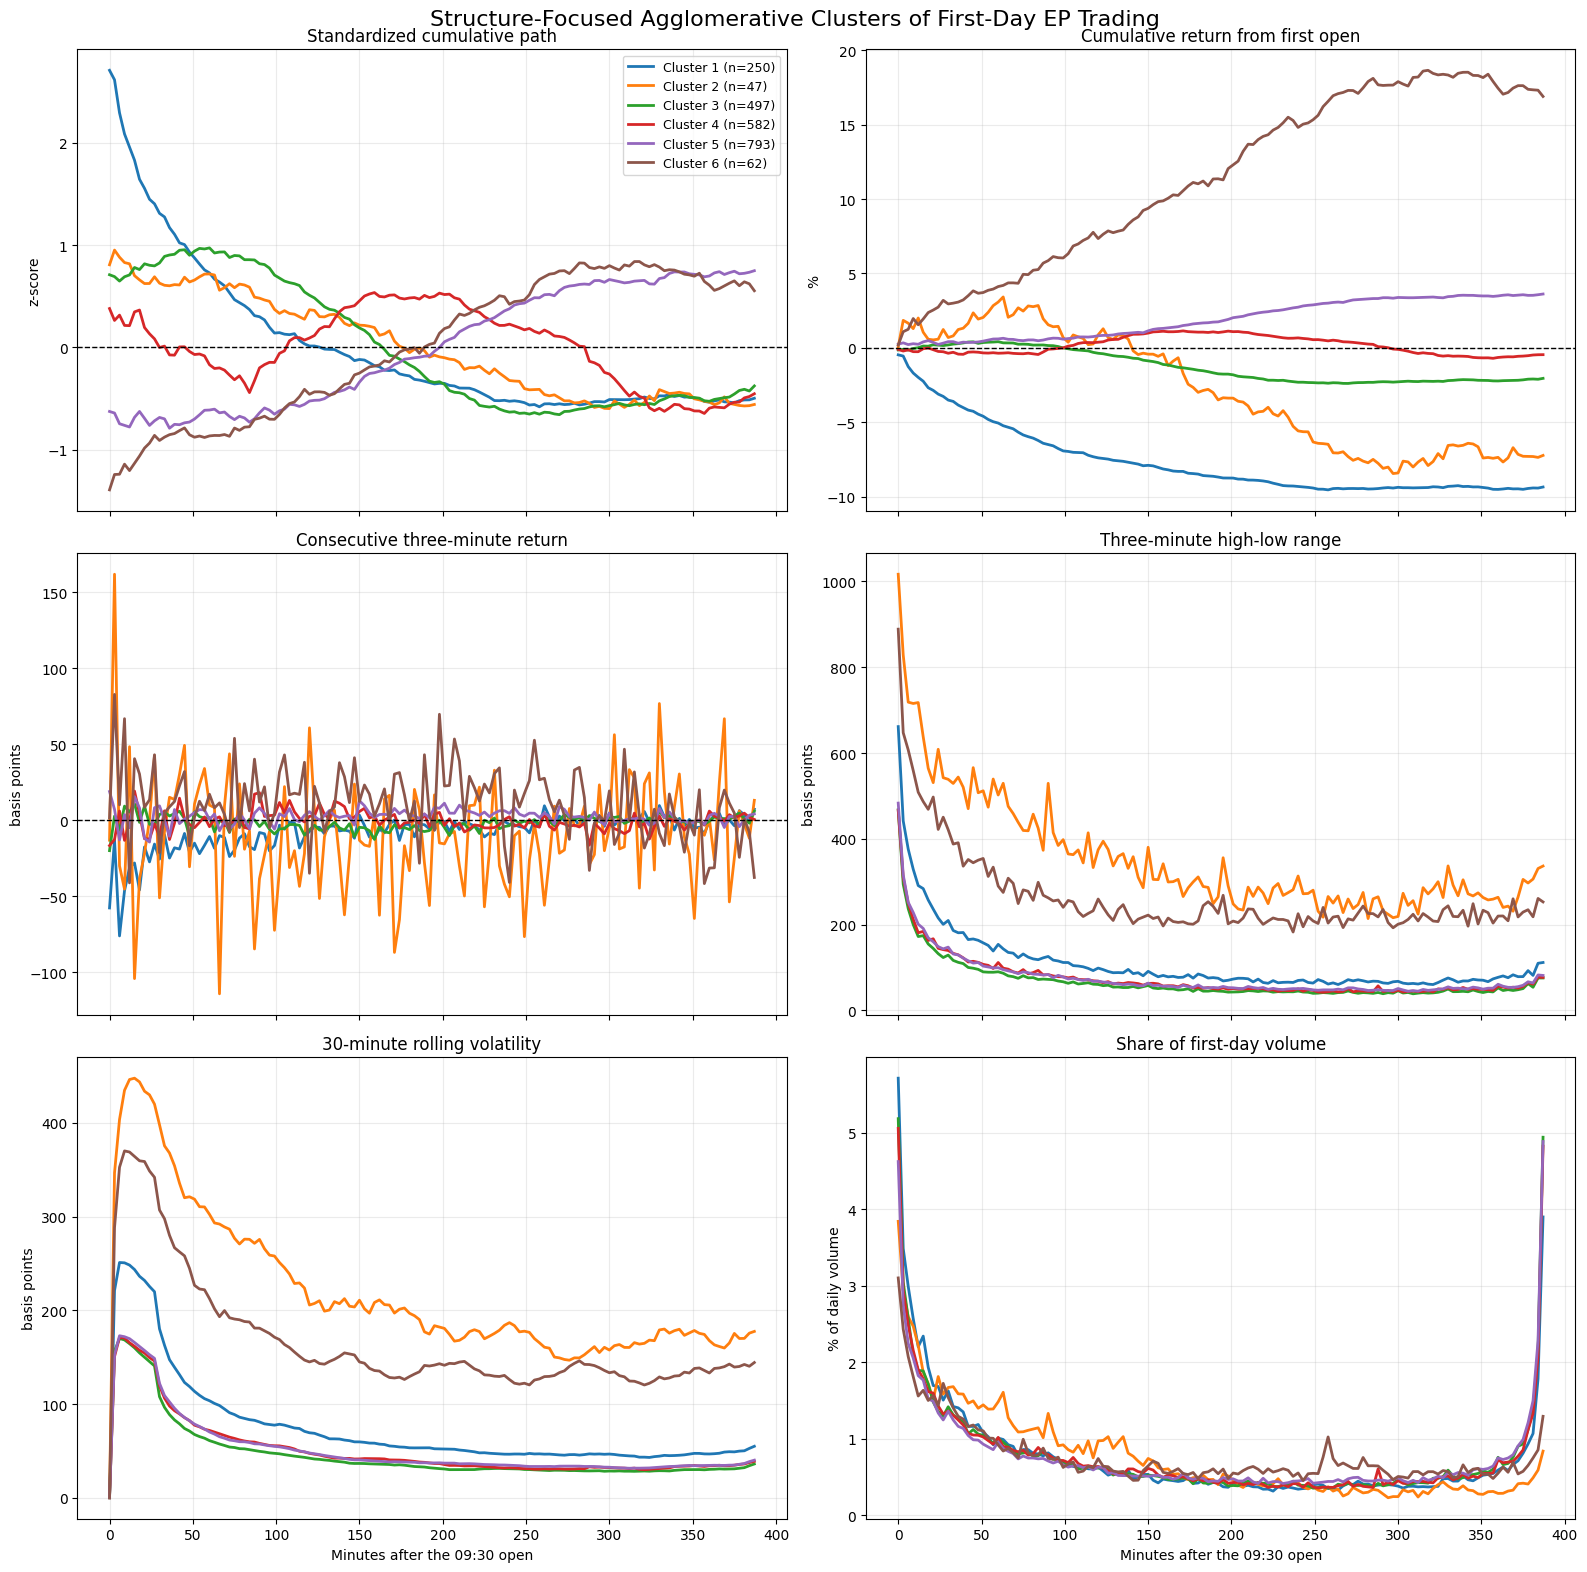

,episodic_pivots,unique_symbols,mean_first_day_return_pct,median_first_day_return_pct,mean_realized_volatility_pct,mean_maximum_drawdown_pct,median_minutes_to_high,median_minutes_to_low,percent_closing_lower
cluster,,,,,,,,,
1,250,211,-9.343884,-9.456497,10.723450,-14.315078,3.0,262.5,89.200000
2,47,20,-7.220800,-16.413963,29.170502,-31.810335,24.0,243.0,59.574468
3,497,423,-2.044855,-1.691542,6.669105,-6.804966,27.0,252.0,68.209256
4,582,478,-0.453042,-1.264356,7.277117,-6.657922,30.0,70.5,62.542955
5,793,585,3.620606,2.821506,7.342479,-5.405245,279.0,27.0,28.751576
6,62,36,16.891102,16.735729,22.001932,-14.440692,271.5,15.0,17.741935


,symbol,ep_start,first_day_open,first_day_return,realized_volatility,maximum_drawdown,minutes_to_high,minutes_to_low,cluster,first_day_return_pct,realized_volatility_pct,maximum_drawdown_pct
0,DOCS,2026-08-07,38.8650,-0.294738,0.125664,-0.267886,0,213,1,-29.473820,12.566350,-26.788596
1,ALMS,2026-01-06,22.2000,-0.268018,0.152216,-0.256111,0,258,1,-26.801802,15.221632,-25.611103
2,TLRY,2026-04-23,9.3000,-0.254839,0.104134,-0.214478,0,375,1,-25.483871,10.413396,-21.447761
3,MNTS,2026-06-08,16.3756,-0.254073,0.128539,-0.238782,9,252,1,-25.407313,12.853937,-23.878205
4,BATL,2026-03-09,24.8500,-0.245223,0.180531,-0.285543,36,366,1,-24.522334,18.053059,-28.554265
...,...,...,...,...,...,...,...,...,...,...,...,...
2226,RXT,2026-05-08,3.8550,0.425422,0.183344,-0.141779,204,0,6,42.542153,18.334372,-14.177852
2227,XNDU,2026-04-15,17.1200,0.466121,0.230619,-0.127868,348,30,6,46.612150,23.061862,-12.786769
2228,ZNTL,2026-04-09,3.0200,0.466887,0.156568,-0.045752,378,6,6,46.688742,15.656799,-4.575163
2229,ACRS,2026-01-20,2.9500,0.498305,0.186785,-0.085755,270,0,6,49.830508,18.678549,-8.575493


In [12]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

STRUCTURE_N_CLUSTERS = 6
STRUCTURE_PCA_COMPONENTS = 40
STRUCTURE_BARS_PER_SESSION = 130
STRUCTURE_MAX_MISSING_BARS = 2

# Weight related feature families after standardization. Time remains aligned:
# feature 0 is always 09:30-09:32, feature 1 is 09:33-09:35, and so on.
STRUCTURE_FEATURE_WEIGHTS = {
    "standardized_path": 2.0,
    "consecutive_return": 2.0,
    "candle_body": 1.0,
    "intraday_range": 1.0,
    "drawdown": 1.0,
    "rolling_volatility": 1.0,
    "relative_volume": 0.75,
}

structure_feature_rows = {
    feature_name: [] for feature_name in STRUCTURE_FEATURE_WEIGHTS
}
structure_raw_paths = []
structure_metadata = []

for ep_row in selected_eps.itertuples(index=False):
    symbol_bars = intraday_3min.get(ep_row.symbol)
    if symbol_bars is None or symbol_bars.empty:
        continue

    first_day = symbol_bars.loc[
        symbol_bars.index.normalize() == ep_row.ep_start,
        ["Open", "High", "Low", "Close", "Volume"],
    ].copy()
    if first_day.empty:
        continue

    minutes_after_midnight = first_day.index.hour * 60 + first_day.index.minute
    first_day["bar_number"] = (
        (minutes_after_midnight - (9 * 60 + 30)) // 3
    )
    first_day = (
        first_day.loc[
            first_day["bar_number"].between(
                0, STRUCTURE_BARS_PER_SESSION - 1
            )
        ]
        .drop_duplicates(subset="bar_number", keep="last")
        .set_index("bar_number")
        .reindex(range(STRUCTURE_BARS_PER_SESSION))
    )

    price_columns = ["Open", "High", "Low", "Close"]
    first_day[price_columns] = first_day[price_columns].interpolate(
        method="linear",
        limit=STRUCTURE_MAX_MISSING_BARS,
        limit_area="inside",
    )
    first_day["Volume"] = first_day["Volume"].interpolate(
        method="linear",
        limit=STRUCTURE_MAX_MISSING_BARS,
        limit_area="inside",
    )

    # Reject partial sessions, large data gaps, invalid prices, and zero-volume days.
    if first_day.isna().any().any():
        continue
    if (first_day[price_columns] <= 0).any().any():
        continue
    if first_day["Volume"].sum() <= 0:
        continue

    first_open = float(first_day.iloc[0]["Open"])
    close = first_day["Close"].astype(float)
    open_ = first_day["Open"].astype(float)
    high = first_day["High"].astype(float)
    low = first_day["Low"].astype(float)
    volume = first_day["Volume"].clip(lower=0).astype(float)

    cumulative_path = close / first_open - 1
    path_scale = cumulative_path.std(ddof=0)
    if not np.isfinite(path_scale) or path_scale == 0:
        continue
    standardized_path = (
        cumulative_path - cumulative_path.mean()
    ) / path_scale

    previous_close = close.shift(1)
    previous_close.iloc[0] = open_.iloc[0]
    consecutive_return = np.log(close / previous_close)
    candle_body = close / open_ - 1
    intraday_range = (high - low) / previous_close
    drawdown = close / close.cummax() - 1
    rolling_volatility = consecutive_return.rolling(
        window=10, min_periods=2
    ).std(ddof=0).fillna(0)
    relative_volume = volume / volume.sum()

    feature_values = {
        "standardized_path": standardized_path.to_numpy(dtype=float),
        "consecutive_return": consecutive_return.to_numpy(dtype=float),
        "candle_body": candle_body.to_numpy(dtype=float),
        "intraday_range": intraday_range.to_numpy(dtype=float),
        "drawdown": drawdown.to_numpy(dtype=float),
        "rolling_volatility": rolling_volatility.to_numpy(dtype=float),
        "relative_volume": relative_volume.to_numpy(dtype=float),
    }
    if not all(np.isfinite(values).all() for values in feature_values.values()):
        continue

    for feature_name, values in feature_values.items():
        structure_feature_rows[feature_name].append(values)
    structure_raw_paths.append(cumulative_path.to_numpy(dtype=float))
    structure_metadata.append(
        {
            "symbol": ep_row.symbol,
            "ep_start": ep_row.ep_start,
            "first_day_open": first_open,
            "first_day_return": float(cumulative_path.iloc[-1]),
            "realized_volatility": float(
                np.sqrt(np.square(consecutive_return).sum())
            ),
            "maximum_drawdown": float(drawdown.min()),
            "minutes_to_high": int(close.to_numpy().argmax() * 3),
            "minutes_to_low": int(close.to_numpy().argmin() * 3),
        }
    )

if len(structure_metadata) < STRUCTURE_N_CLUSTERS:
    raise ValueError(
        f"Only {len(structure_metadata)} complete first-day sessions are "
        f"available for {STRUCTURE_N_CLUSTERS} clusters."
    )

# Scale each time-of-day feature across EPs, then apply family weights. This
# removes units and magnitude differences without moving patterns in time.
scaled_structure_blocks = []
structure_block_scalers = {}
for feature_name, weight in STRUCTURE_FEATURE_WEIGHTS.items():
    feature_matrix = np.vstack(structure_feature_rows[feature_name])
    scaler = StandardScaler()
    scaled_structure_blocks.append(
        scaler.fit_transform(feature_matrix) * weight
    )
    structure_block_scalers[feature_name] = scaler

structure_feature_matrix = np.hstack(scaled_structure_blocks)
structure_pca_components = min(
    STRUCTURE_PCA_COMPONENTS,
    structure_feature_matrix.shape[0] - 1,
    structure_feature_matrix.shape[1],
)
structure_pca = PCA(n_components=structure_pca_components)
structure_embedding = structure_pca.fit_transform(structure_feature_matrix)

structure_cluster_model = AgglomerativeClustering(
    n_clusters=STRUCTURE_N_CLUSTERS,
    linkage="ward",
)
raw_structure_labels = structure_cluster_model.fit_predict(structure_embedding)
structure_raw_paths_matrix = np.vstack(structure_raw_paths)

# Renumber arbitrary model labels by mean closing return for easier comparison.
raw_label_final_returns = {
    label: structure_raw_paths_matrix[raw_structure_labels == label, -1].mean()
    for label in np.unique(raw_structure_labels)
}
ordered_structure_labels = sorted(
    raw_label_final_returns, key=raw_label_final_returns.get
)
structure_label_map = {
    original_label: cluster_number
    for cluster_number, original_label in enumerate(
        ordered_structure_labels, start=1
    )
}
structure_labels = np.array(
    [structure_label_map[label] for label in raw_structure_labels]
)

structure_cluster_assignments = pd.DataFrame(structure_metadata)
structure_cluster_assignments["cluster"] = structure_labels
for column in [
    "first_day_return",
    "realized_volatility",
    "maximum_drawdown",
]:
    structure_cluster_assignments[f"{column}_pct"] = (
        structure_cluster_assignments[column] * 100
    )

structure_cluster_summary = (
    structure_cluster_assignments.groupby("cluster")
    .agg(
        episodic_pivots=("symbol", "size"),
        unique_symbols=("symbol", "nunique"),
        mean_first_day_return_pct=("first_day_return_pct", "mean"),
        median_first_day_return_pct=("first_day_return_pct", "median"),
        mean_realized_volatility_pct=("realized_volatility_pct", "mean"),
        mean_maximum_drawdown_pct=("maximum_drawdown_pct", "mean"),
        median_minutes_to_high=("minutes_to_high", "median"),
        median_minutes_to_low=("minutes_to_low", "median"),
        percent_closing_lower=(
            "first_day_return",
            lambda returns: returns.lt(0).mean() * 100,
        ),
    )
    .sort_index()
)

structure_explained_variance = structure_pca.explained_variance_ratio_.sum()
print(
    f"Clustered {len(structure_cluster_assignments):,} complete EP sessions | "
    f"PCA components: {structure_pca_components} | "
    f"Explained variance: {structure_explained_variance:.1%}"
)

# Plot raw quantities for interpretation even though clustering used scaled,
# weighted, and PCA-denoised features.
minutes = np.arange(STRUCTURE_BARS_PER_SESSION) * 3
raw_feature_matrices = {
    name: np.vstack(rows) for name, rows in structure_feature_rows.items()
}
fig, axes = plt.subplots(3, 2, figsize=(16, 16), sharex=True)
plot_specs = [
    ("standardized_path", "Standardized cumulative path", "z-score"),
    ("raw_path", "Cumulative return from first open", "%"),
    ("consecutive_return", "Consecutive three-minute return", "basis points"),
    ("intraday_range", "Three-minute high-low range", "basis points"),
    ("rolling_volatility", "30-minute rolling volatility", "basis points"),
    ("relative_volume", "Share of first-day volume", "% of daily volume"),
]

for ax, (feature_name, title, ylabel) in zip(axes.flat, plot_specs):
    matrix = (
        structure_raw_paths_matrix
        if feature_name == "raw_path"
        else raw_feature_matrices[feature_name]
    )
    multiplier = 1
    if feature_name in {"raw_path", "relative_volume"}:
        multiplier = 100
    elif feature_name in {
        "consecutive_return",
        "intraday_range",
        "rolling_volatility",
    }:
        multiplier = 10_000

    for cluster_number in range(1, STRUCTURE_N_CLUSTERS + 1):
        cluster_values = matrix[structure_labels == cluster_number] * multiplier
        ax.plot(
            minutes,
            cluster_values.mean(axis=0),
            linewidth=2,
            label=f"Cluster {cluster_number} (n={len(cluster_values):,})",
        )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    if feature_name in {"standardized_path", "raw_path", "consecutive_return"}:
        ax.axhline(0, color="black", linewidth=1, linestyle="--")

for ax in axes[-1, :]:
    ax.set_xlabel("Minutes after the 09:30 open")
axes[0, 0].legend(fontsize=9)
fig.suptitle(
    "Structure-Focused Agglomerative Clusters of First-Day EP Trading",
    fontsize=16,
)
plt.tight_layout()
plt.show()

display(structure_cluster_summary)
display(
    structure_cluster_assignments.sort_values(
        ["cluster", "first_day_return"], ascending=[True, True]
    ).reset_index(drop=True)
)

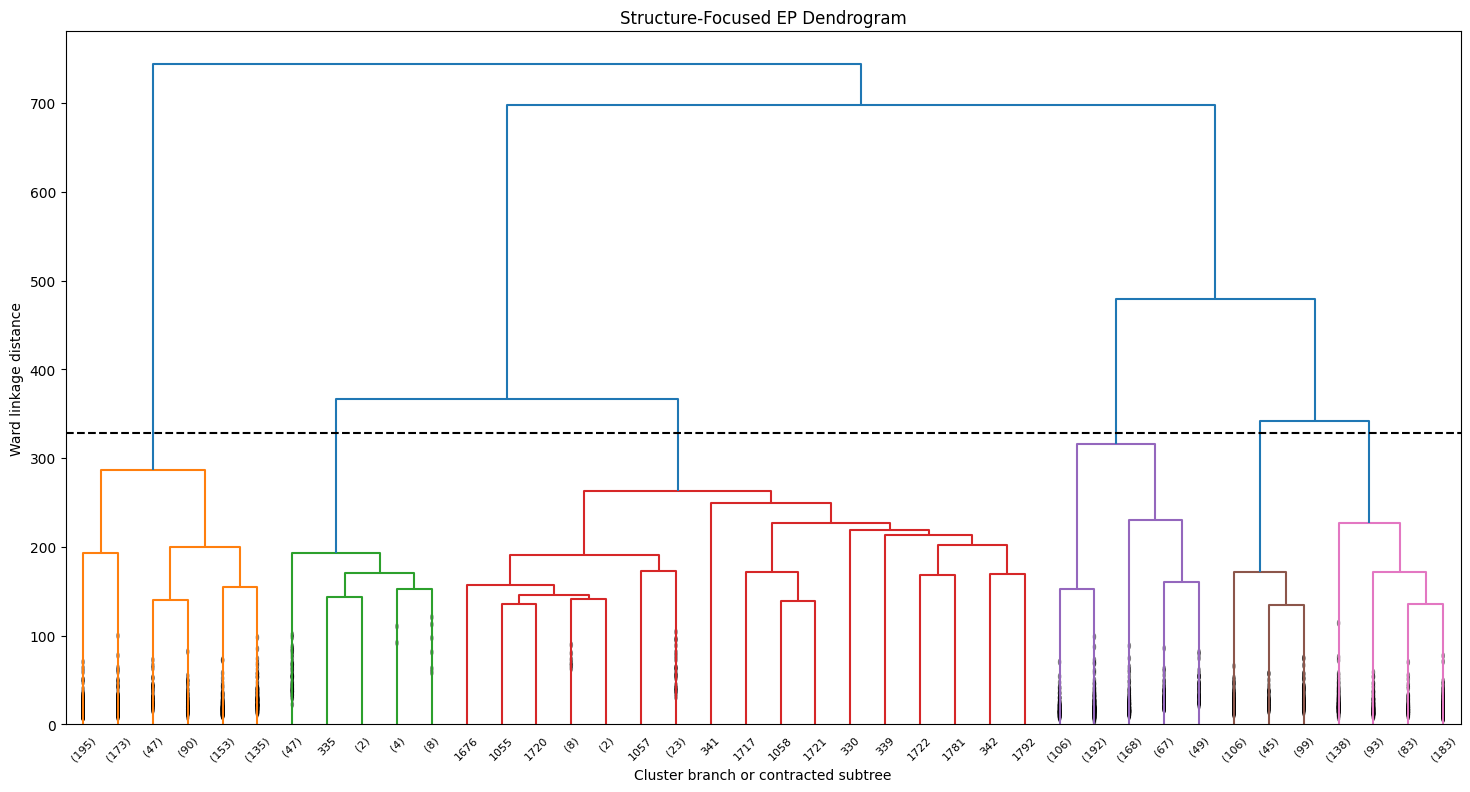

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

structure_linkage = linkage(
    structure_embedding,
    method="ward",
    metric="euclidean",
)

# Threshold corresponding approximately to six clusters.
cut_threshold = (
    structure_linkage[-STRUCTURE_N_CLUSTERS, 2]
    + structure_linkage[-(STRUCTURE_N_CLUSTERS - 1), 2]
) / 2

plt.figure(figsize=(18, 9))
dendrogram(
    structure_linkage,
    truncate_mode="lastp",
    p=40,
    show_contracted=True,
    color_threshold=cut_threshold,
)
plt.axhline(cut_threshold, color="black", linestyle="--")
plt.title("Structure-Focused EP Dendrogram")
plt.xlabel("Cluster branch or contracted subtree")
plt.ylabel("Ward linkage distance")
plt.show()

- For retrieving subtree members

,x_position,display_label,linkage_node,observations
0,0,(195),4404,195
1,1,(173),4410,173
2,2,(47),4387,47
3,3,(90),4401,90
4,4,(153),4386,153
5,5,(135),4416,135
6,6,(47),4407,47
7,7,335,335,1
8,8,(2),4420,2
9,9,(4),4412,4


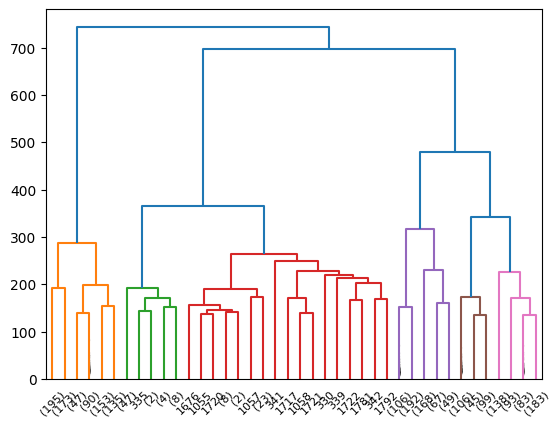

In [14]:
from scipy.cluster.hierarchy import dendrogram, to_tree

dendrogram_result = dendrogram(
    structure_linkage,
    truncate_mode="lastp",
    p=40,
    show_contracted=True,
    color_threshold=cut_threshold,
)

_, linkage_nodes = to_tree(structure_linkage, rd=True)

contracted_subtree_members = {}
subtree_summary = []

for position, node_id in enumerate(dendrogram_result["leaves"]):
    observation_indices = linkage_nodes[node_id].pre_order(
        lambda leaf: leaf.id
    )

    members = structure_cluster_assignments.iloc[
        observation_indices
    ].copy()
    members["observation_index"] = observation_indices

    contracted_subtree_members[position] = members

    subtree_summary.append(
        {
            "x_position": position,
            "display_label": dendrogram_result["ivl"][position],
            "linkage_node": node_id,
            "observations": len(members),
        }
    )

subtree_summary = pd.DataFrame(subtree_summary)
display(subtree_summary)

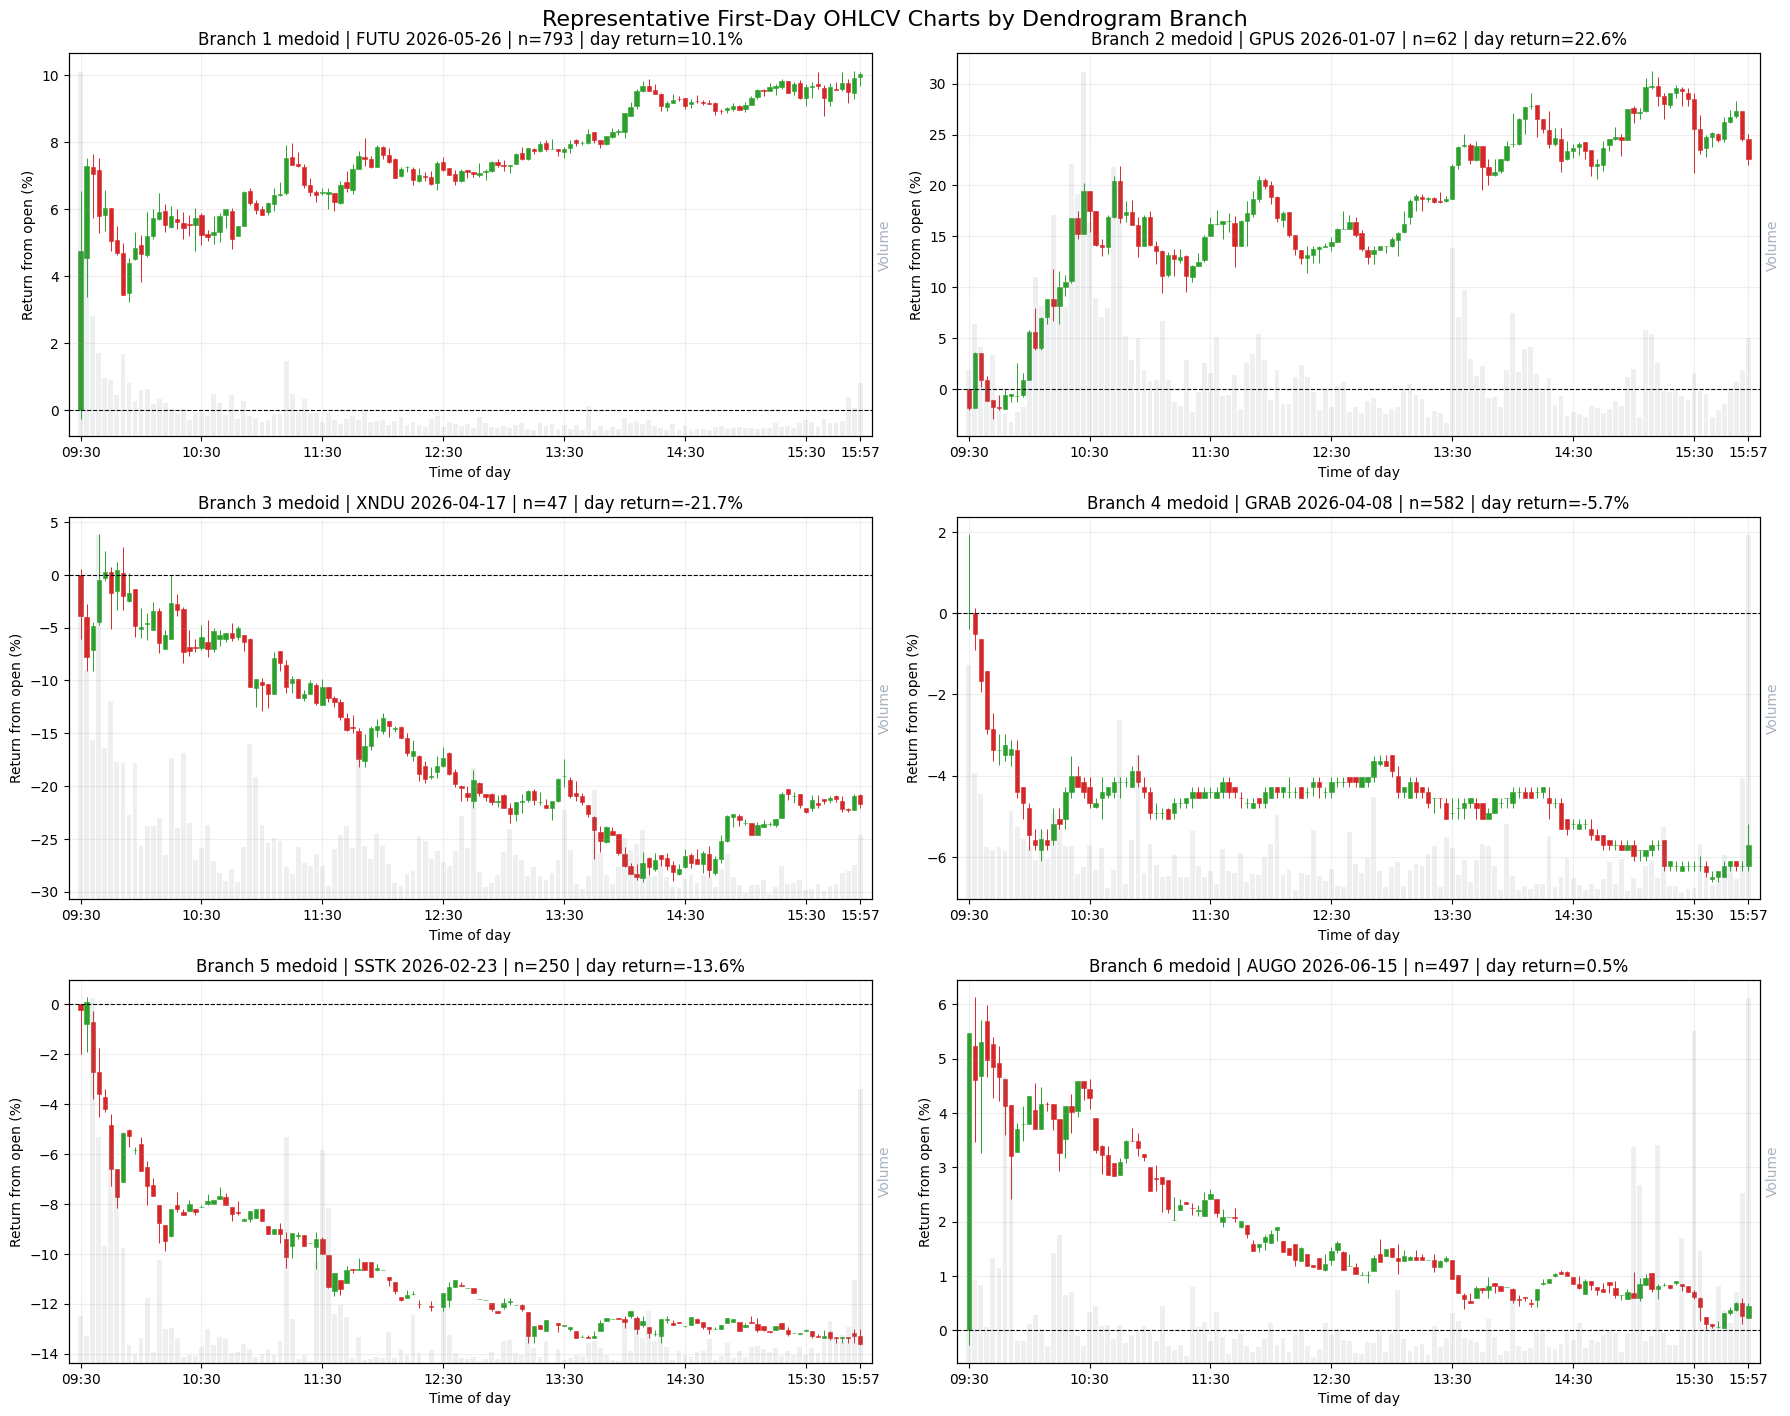

Dendrogram cut at 328.794 produced 6 branches.


,dendrogram_cluster,representative_rank,is_medoid,cluster_size,symbol,ep_start,first_day_return_pct,realized_volatility_pct,maximum_drawdown_pct,distance_from_medoid
0,1,1,True,793,FUTU,2026-05-26,10.050559,6.445700,-3.597277,0.000000
1,1,2,False,793,WHD,2026-07-30,9.234035,4.937354,-1.755008,10.694907
2,1,3,False,793,ENLT,2026-02-17,5.899705,4.067333,-2.435308,11.410232
3,2,1,True,62,GPUS,2026-01-07,22.633034,17.299005,-7.747489,0.000000
4,2,2,False,62,BATL,2026-07-13,8.139535,16.139096,-8.398950,32.737320
5,2,3,False,62,IBRX,2026-01-16,17.485106,16.450747,-6.935333,33.665333
6,3,1,True,47,XNDU,2026-04-17,-21.688312,18.714979,-29.012665,0.000000
7,3,2,False,47,BATL,2026-03-06,-11.898634,23.416286,-28.924768,37.165604
8,3,3,False,47,ALLO,2026-04-13,-25.427873,14.380140,-29.725122,41.101374
9,4,1,True,582,GRAB,2026-04-08,-5.706874,3.379295,-6.485084,0.000000


In [15]:
from scipy.cluster.hierarchy import fcluster
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

REPRESENTATIVES_PER_CLUSTER = 3

# Use the same horizontal boundary displayed on the dendrogram. Each resulting
# label therefore corresponds to one branch below the dashed cut line.
dendrogram_labels = fcluster(
    structure_linkage,
    t=cut_threshold,
    criterion="distance",
)
dendrogram_cluster_count = int(np.unique(dendrogram_labels).size)

if len(dendrogram_labels) != len(structure_cluster_assignments):
    raise ValueError(
        "The linkage observations and structure-cluster metadata are not aligned."
    )

# Preserve the original observation order used to build structure_embedding.
dendrogram_cluster_assignments = (
    structure_cluster_assignments.copy().reset_index(drop=True)
)
dendrogram_cluster_assignments["dendrogram_cluster"] = dendrogram_labels

# A medoid is an actual EP observation that minimizes its average distance to
# all other members of its dendrogram branch. The additional representatives
# are the observations nearest to that medoid.
representative_rows = []
for cluster_number in sorted(np.unique(dendrogram_labels)):
    cluster_indices = np.flatnonzero(dendrogram_labels == cluster_number)
    cluster_embedding = structure_embedding[cluster_indices]
    within_cluster_distances = cdist(
        cluster_embedding,
        cluster_embedding,
        metric="euclidean",
    )
    medoid_local_index = int(
        within_cluster_distances.mean(axis=1).argmin()
    )
    distance_from_medoid = within_cluster_distances[medoid_local_index]
    nearest_local_indices = np.argsort(distance_from_medoid)[
        : min(REPRESENTATIVES_PER_CLUSTER, len(cluster_indices))
    ]

    for representative_rank, local_index in enumerate(
        nearest_local_indices, start=1
    ):
        observation_index = int(cluster_indices[local_index])
        observation = dendrogram_cluster_assignments.iloc[observation_index]
        representative_rows.append(
            {
                "dendrogram_cluster": int(cluster_number),
                "representative_rank": representative_rank,
                "is_medoid": representative_rank == 1,
                "cluster_size": len(cluster_indices),
                "symbol": observation["symbol"],
                "ep_start": observation["ep_start"],
                "first_day_return_pct": observation["first_day_return_pct"],
                "realized_volatility_pct": observation[
                    "realized_volatility_pct"
                ],
                "maximum_drawdown_pct": observation[
                    "maximum_drawdown_pct"
                ],
                "distance_from_medoid": float(
                    distance_from_medoid[local_index]
                ),
                "observation_index": observation_index,
            }
        )

representative_ep_charts = pd.DataFrame(representative_rows)
dendrogram_cluster_medoids = representative_ep_charts.loc[
    representative_ep_charts["is_medoid"]
].copy()


def _plot_representative_ep(ax, representative):
    symbol = representative["symbol"]
    ep_start = pd.Timestamp(representative["ep_start"]).normalize()
    symbol_bars = intraday_3min.get(symbol)
    if symbol_bars is None or symbol_bars.empty:
        ax.set_visible(False)
        return

    session = symbol_bars.loc[
        symbol_bars.index.normalize() == ep_start,
        ["Open", "High", "Low", "Close", "Volume"],
    ].copy()
    session = session.apply(pd.to_numeric, errors="coerce").dropna()
    if session.empty:
        ax.set_visible(False)
        return

    minutes_after_midnight = session.index.hour * 60 + session.index.minute
    x = np.asarray(
        (minutes_after_midnight - (9 * 60 + 30)) / 3,
        dtype=float,
    )
    first_open = float(session.iloc[0]["Open"])
    open_return = (session["Open"].to_numpy() / first_open - 1) * 100
    high_return = (session["High"].to_numpy() / first_open - 1) * 100
    low_return = (session["Low"].to_numpy() / first_open - 1) * 100
    close_return = (session["Close"].to_numpy() / first_open - 1) * 100
    up_bar = close_return >= open_return
    colors = np.where(up_bar, "#2ca02c", "#d62728")

    ax.vlines(x, low_return, high_return, color=colors, linewidth=0.7)
    ax.bar(
        x,
        np.abs(close_return - open_return),
        bottom=np.minimum(open_return, close_return),
        width=0.72,
        color=colors,
        edgecolor=colors,
        linewidth=0.4,
    )
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.grid(alpha=0.2)
    ax.set_xlim(-2, STRUCTURE_BARS_PER_SESSION + 1)
    ax.set_ylabel("Return from open (%)")
    ax.set_title(
        f"Branch {int(representative['dendrogram_cluster'])} medoid | "
        f"{symbol} {ep_start:%Y-%m-%d} | "
        f"n={int(representative['cluster_size']):,} | "
        f"day return={representative['first_day_return_pct']:.1f}%"
    )

    volume_axis = ax.twinx()
    volume_axis.bar(
        x,
        session["Volume"].to_numpy(),
        width=0.8,
        color="slategray",
        alpha=0.12,
    )
    volume_axis.set_yticks([])
    volume_axis.set_ylabel("Volume", color="slategray", alpha=0.6)

    tick_positions = np.array([0, 20, 40, 60, 80, 100, 120, 129])
    tick_minutes = 9 * 60 + 30 + tick_positions * 3
    tick_labels = [
        f"{minute // 60:02d}:{minute % 60:02d}" for minute in tick_minutes
    ]
    ax.set_xticks(tick_positions, tick_labels)
    ax.set_xlabel("Time of day")


figure_rows = int(np.ceil(dendrogram_cluster_count / 2))
fig, axes = plt.subplots(
    figure_rows,
    2,
    figsize=(18, 4.8 * figure_rows),
    squeeze=False,
)
for ax, (_, medoid) in zip(axes.flat, dendrogram_cluster_medoids.iterrows()):
    _plot_representative_ep(ax, medoid)
for ax in axes.flat[len(dendrogram_cluster_medoids) :]:
    ax.set_visible(False)

fig.suptitle(
    "Representative First-Day OHLCV Charts by Dendrogram Branch",
    fontsize=16,
)
plt.tight_layout()
plt.show()

print(
    f"Dendrogram cut at {cut_threshold:.3f} produced "
    f"{dendrogram_cluster_count} branches."
)
display(
    representative_ep_charts.drop(columns="observation_index").sort_values(
        ["dendrogram_cluster", "representative_rank"]
    )
)